In [131]:
"""ML"""
import torch
import torch.nn.functional as F
import numpy as np

"""Visualization"""
from matplotlib import pyplot as plt

"""Dataset and Preprocessing"""
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

"""Utils"""
# Add Base directory to Python path
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from Utils.paths import *
import Utils.plotting as plotting
import Utils.json_inter as json_inter 

from tqdm import tqdm

torch.manual_seed(0)
np.random.seed(0)

%load_ext autoreload
%autoreload 2

torch.__version__, np.__version__

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


('2.5.1+cu118', '2.0.1')

In [132]:
PATHS

{'BASE_DIR': 'D:\\Repos\\FPGA_Radar_Microdoppler_Classification',
 'OUTPUTS': 'D:\\Repos\\FPGA_Radar_Microdoppler_Classification\\Outputs',
 'NOTEBOOKS': 'D:\\Repos\\FPGA_Radar_Microdoppler_Classification\\Notebooks',
 'ASSETS': 'D:\\Repos\\FPGA_Radar_Microdoppler_Classification\\Assets',
 'DATASET': 'D:\\Repos\\FPGA_Radar_Microdoppler_Classification\\Assets\\Dataset',
 'PROCESSED_DATASETS': 'D:\\Repos\\FPGA_Radar_Microdoppler_Classification\\Assets\\Dataset\\Processed',
 'MODELS': 'D:\\Repos\\FPGA_Radar_Microdoppler_Classification\\Assets\\Models',
 'LOGS': 'D:\\Repos\\FPGA_Radar_Microdoppler_Classification\\Logs',
 'UTILS': 'D:\\Repos\\FPGA_Radar_Microdoppler_Classification\\Utils'}

{'vehicle': 201, 'person': 52, 'bicycle': 47, 'uav': 50}


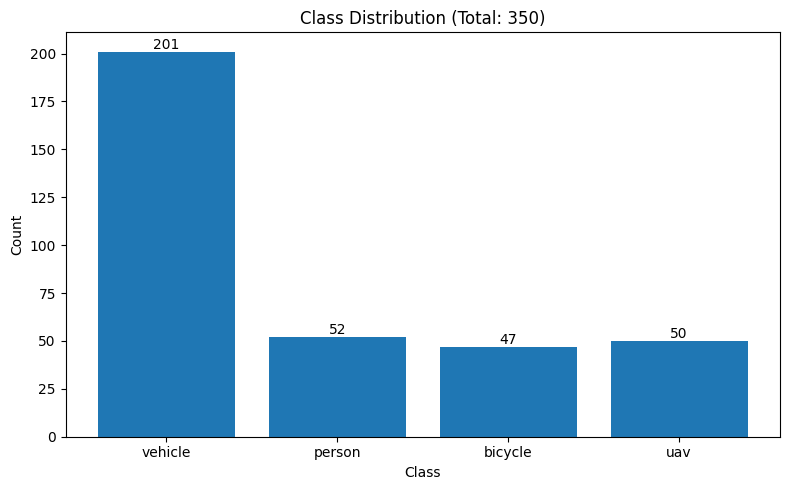

In [133]:
filename = PATHS['DATASET'] + "/moving_target_dataset.npy"
signatures = np.load(filename, allow_pickle=True)

class_names = []
class_counts = {}
signature_bin_size = []
for signature in signatures:
    if not any(signature['class_name'] in s for s in class_names):
        class_names.append(signature['class_name'])
    class_counts[signature['class_name']] = class_counts.get(signature['class_name'], 0) + 1
    signature_bin_size.append(signature['signature'].shape[0])

print(class_counts)

# Extract keys and values
classes = list(class_counts.keys())
counts = list(class_counts.values())

plotting.plot_histogram_from_dict(class_counts, title=f"Class Distribution (Total: {sum(counts)})")

***
## Preprocessing Pipeline V1

### 1. Generate All Windows Per Track
For each track:
1. ~~Sort detections by timestamp~~ - timestamps are already sorted
2. Optionally SNR-filter.
3. Slide window of size K with stride S.

Store:
- Window tensor (K, 1008)
- Class label
- Metadata
- track ID

At this stage, nothing is discarded yet (even with class imbalances)

### 2. Class Balancing
1. Count windows per class.
2. Identify minimum class count.
3. Pseudo-randomly downsample other classes to match.
4. Shuffle final dataset.

In [134]:
# from collections import defaultdict
# from sklearn.model_selection import train_test_split

# CONFIG = json_inter.read_json_config(NOTEBOOKS + "\\preprocess.config")

In [135]:
# def sort_track(sig):
#     order = np.argsort(sig["ts"])
#     for key in ["signature", "ts", "velocity", "azimuth",
#                 "range", "snr_db"]:
#         sig[key] = np.array(sig[key])[order]
#     return sig
# def generate_windows_from_track(sig, config):
    
#     sig = sort_track(sig)
    
#     signature = sig["signature"]
#     velocity = np.array(sig["velocity"])
#     azimuth = np.array(sig["azimuth"])
#     rng = np.array(sig["range"])
#     snr = np.array(sig["snr_db"])
    
#     if config["snr_threshold"] is not None:
#         mask = snr >= config["snr_threshold"]
#         signature = signature[mask]
#         velocity = velocity[mask]
#         azimuth = azimuth[mask]
#         rng = rng[mask]
    
#     N, D = signature.shape
#     K = CONFIG["window_size"]
#     stride = config["stride"]
    
#     windows = []
    
#     if N < K:
#         return windows
    
#     for start in range(0, N - K + 1, stride):
#         end = start + K
        
#         window = signature[start:end]
#         window = np.log(np.abs(window) + 1e-8)
        
#         metadata = {
#             "mean_velocity": float(np.mean(velocity[start:end])),
#             "std_velocity": float(np.std(velocity[start:end])),
#             "mean_azimuth": float(np.mean(azimuth[start:end])),
#             "std_azimuth": float(np.std(azimuth[start:end])),
#             "mean_range": float(np.mean(rng[start:end])),
#             "std_range": float(np.std(rng[start:end])),
#             "mean_snr": float(np.mean(snr[start:end]))
#         }
        
#         windows.append({
#             "window": window,
#             "label": sig["class_name"],
#             "track_id": sig["id"],
#             "metadata": metadata
#         })
    
#     return windows
# def split_tracks(signatures, config):
#     np.random.seed(config["random_seed"])
    
#     track_ids = [sig["id"] for sig in signatures]
#     labels = [sig["class_name"] for sig in signatures]
    
#     train_ids, test_ids = train_test_split(
#         track_ids,
#         test_size=config["test_size"],
#         stratify=labels,
#         random_state=config["random_seed"]
#     )
    
#     train_sigs = [sig for sig in signatures if sig["id"] in train_ids]
#     test_sigs = [sig for sig in signatures if sig["id"] in test_ids]
    
#     # Split validation from train
#     train_ids = [sig["id"] for sig in train_sigs]
#     train_labels = [sig["class_name"] for sig in train_sigs]
    
#     train_ids_final, val_ids = train_test_split(
#         train_ids,
#         test_size=config["val_size"],
#         stratify=train_labels,
#         random_state=config["random_seed"]
#     )
    
#     train_final = [sig for sig in train_sigs if sig["id"] in train_ids_final]
#     val_sigs = [sig for sig in train_sigs if sig["id"] in val_ids]
    
#     return train_final, val_sigs, test_sigs
# def build_window_dataset(track_list, config):
#     dataset = []
    
#     for sig in track_list:
#         windows = generate_windows_from_track(sig, config)
#         dataset.extend(windows)
    
#     return dataset
# def balance_dataset(dataset, config):
#  if not config["balance_classes"]:
#      return dataset
 
#  np.random.seed(config["random_seed"])
 
#  groups = defaultdict(list)
#  for item in dataset:
#      groups[item["label"]].append(item)
 
#  min_size = min(len(v) for v in groups.values())
 
#  balanced = []
#  for label, items in groups.items():
#      indices = np.random.choice(len(items),
#                                 size=min_size,
#                                 replace=False)
#      balanced.extend([items[i] for i in indices])
 
#  np.random.shuffle(balanced)
#  return balanced
# def convert_to_arrays(dataset):
#     X, y, meta, track_ids = [], [], [], []
    
#     for item in dataset:
#         X.append(item["window"])
#         y.append(item["label"])
#         meta.append(item["metadata"])
#         track_ids.append(item["track_id"])
    
#     X = np.array(X)[:, None, :, :]  # Add channel dim
#     y = np.array(y)
    
#     return X, y, meta, track_ids
# def save_dataset(train, val, test, config):
    
#     filename = (
#         f"{config['dataset_name']}"
#         f"_K{config['window_size']}"
#         f"_S{config['stride']}"
#         f"_SNR{config['snr_threshold']}.npz"
#     )
    
#     # path = PATHS['PROCESSED_DATASETS'] + "\\" + filename
    
#     path = PATHS['PROCESSED_DATASETS'] + "\\" + filename
#     config["file_path"] = path
#     json_inter.save_config_to_json(config, "preprocess_config", filename.replace(".npz", ""))
#     np.savez_compressed(
#         path,
#         train_X=train[0],
#         train_y=train[1],
#         val_X=val[0],
#         val_y=val[1],
#         test_X=test[0],
#         test_y=test[1],
#         config=config
#     )
    
#     print(f"Saved dataset to: {path}")
# # 1️ Split tracks
# train_tracks, val_tracks, test_tracks = split_tracks(signatures, CONFIG)

# # 2️ Build window datasets
# train_data = build_window_dataset(train_tracks, CONFIG)
# val_data = build_window_dataset(val_tracks, CONFIG)
# test_data = build_window_dataset(test_tracks, CONFIG)

# # 3️ Balance each split independently
# train_data = balance_dataset(train_data, CONFIG)
# # val_data = balance_dataset(val_data, CONFIG)
# # test_data = balance_dataset(test_data, CONFIG)

# # 4️ Convert to arrays
# train_arrays = convert_to_arrays(train_data)
# val_arrays = convert_to_arrays(val_data)
# test_arrays = convert_to_arrays(test_data)

# # 5 Save dataset
# save_dataset(train_arrays, val_arrays, test_arrays, CONFIG)
# CONFIG['window_size'] = 64
# # 1️ Split tracks
# train_tracks, val_tracks, test_tracks = split_tracks(signatures, CONFIG)

# # 2️ Build window datasets
# train_data = build_window_dataset(train_tracks, CONFIG)
# # val_data = build_window_dataset(val_tracks, CONFIG)
# # test_data = build_window_dataset(test_tracks, CONFIG)

# # 3️ Balance each split independently
# train_data = balance_dataset(train_data, CONFIG)
# # val_data = balance_dataset(val_data, CONFIG)
# # test_data = balance_dataset(test_data, CONFIG)

# # 4️ Convert to arrays
# train_arrays = convert_to_arrays(train_data)
# val_arrays = convert_to_arrays(val_data)
# test_arrays = convert_to_arrays(test_data)
# save_dataset(train_arrays, val_arrays, test_arrays, CONFIG)
# CONFIG['window_size'] = 256
# # 1️ Split tracks
# train_tracks, val_tracks, test_tracks = split_tracks(signatures, CONFIG)

# # 2️ Build window datasets
# train_data = build_window_dataset(train_tracks, CONFIG)
# val_data = build_window_dataset(val_tracks, CONFIG)
# test_data = build_window_dataset(test_tracks, CONFIG)

# # 3️ Balance each split independently
# train_data = balance_dataset(train_data, CONFIG)
# # val_data = balance_dataset(val_data, CONFIG)
# # test_data = balance_dataset(test_data, CONFIG)

# # 4️ Convert to arrays
# train_arrays = convert_to_arrays(train_data)
# val_arrays = convert_to_arrays(val_data)
# test_arrays = convert_to_arrays(test_data)
# save_dataset(train_arrays, val_arrays, test_arrays, CONFIG)
# json_inter.load_config_as_dataframe("preprocess_config")
# from collections import Counter

# def print_class_counts(dataset, name):
#     counts = Counter([item["label"] for item in dataset])
#     print(f"\n{name} distribution:")
#     for k, v in counts.items():
#         print(f"{k}: {v}")
#     print(f"Total: {sum(counts.values())}")

# print_class_counts(train_data, "Train (before balance)")
# print_class_counts(val_data, "Val (before balance)")
# print_class_counts(test_data, "Test (before balance)")

#### Shortfalls of V1

#### **TODO**
***

## Preprocessing Pipeline V2
1. Estimate Doppler temporal correlation length - to use the lag as stride
2. Tracks 80/10/10
3. Generate windows
4. No post window extraction balancing
5. Use class-weighted loss for imbalanced classes


Each track has multiple windows. Once windows have been extracted, multiple windows (from a single track) highly identical (correlated) to one another exist. Splitting those into train, test, validation sets will defeat the point of test and validation datasets. Data in test and validation sets, from the models point of view, should be data thats never been seen before.

As for the doppler temporal correlation length. The minimum length or the lag is kept as the stride so as to not have train data (windows) near identical to one another, and also just enough stride so as to keep related activations together. This kind of stride keeps nearby windows statistically independent.

In [136]:
# from collections import defaultdict

# CONFIG = json_inter.read_json_config(NOTEBOOKS + "\\preprocess.config")
# import numpy as np
# from tqdm import tqdm
# from collections import defaultdict
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import LabelEncoder


# def assign_track_ids(signatures):
#     for i, sig in enumerate(signatures):
#         sig["track_id"] = i
#     return signatures

# def encode_labels(signatures):
#     le = LabelEncoder()
#     class_names = [sig["class_name"] for sig in signatures]
#     le.fit(class_names)

#     for sig in signatures:
#         sig["class_idx"] = le.transform([sig["class_name"]])[0]

#     return le


# def estimate_correlation_stride(signatures, config):

#     correlations = []

#     sample_subset = signatures[:min(20, len(signatures))]

#     for sig in sample_subset:
#         X = np.abs(sig["signature"])
#         energy = np.mean(X, axis=1)

#         energy = (energy - energy.mean()) / (energy.std() + 1e-8)

#         max_lag = min(config["max_lag"], len(energy) - 1)

#         for lag in range(1, max_lag):
#             corr = np.corrcoef(energy[:-lag], energy[lag:])[0, 1]
#             correlations.append((lag, corr))

#     lag_dict = defaultdict(list)
#     for lag, corr in correlations:
#         lag_dict[lag].append(corr)

#     for lag in sorted(lag_dict.keys()):
#         mean_corr = np.mean(lag_dict[lag])
#         if mean_corr < config["correlation_threshold"]:
#             print(f"Estimated correlation stride: {lag}")
#             return lag

#     fallback = config["window_size"] // 2
#     print(f"Using fallback stride: {fallback}")
#     return fallback


# def split_tracks(signatures, config):

#     track_ids = [sig["track_id"] for sig in signatures]
#     labels = [sig["class_idx"] for sig in signatures]

#     # 80/20 split 
#     train_ids, test_ids = train_test_split(
#         track_ids,
#         test_size=config["test_size"],
#         stratify=labels,
#         random_state=config["random_seed"]
#     )

#     train_sigs = [s for s in signatures if s["track_id"] in train_ids]
#     test_sigs  = [s for s in signatures if s["track_id"] in test_ids]

#     # Split train into train/val
#     train_track_ids = [s["track_id"] for s in train_sigs]
#     train_labels = [s["class_idx"] for s in train_sigs]

#     train_ids_final, val_ids = train_test_split(
#         train_track_ids,
#         test_size=config["val_size"],
#         stratify=train_labels,
#         random_state=config["random_seed"]
#     )

#     train_final = [s for s in train_sigs if s["track_id"] in train_ids_final]
#     val_sigs    = [s for s in train_sigs if s["track_id"] in val_ids]

#     return train_final, val_sigs, test_sigs


# def generate_windows(track_list, config, stride):

#     dataset = []

#     for sig in tqdm(track_list, desc="Generating windows"):
#         X = np.abs(sig["signature"])
#         X = np.log(X + 1e-8)

#         N, D = X.shape
#         K = config["window_size"]

#         if N < K:
#             continue

#         for start in range(0, N - K + 1, stride):
#             end = start + K
#             window = X[start:end]

#             dataset.append({
#                 "window": window,
#                 "label": sig["class_idx"],
#                 "track_id": sig["track_id"]
#             })

#     return dataset



# def convert_to_arrays(dataset):
#     X = np.array([d["window"] for d in dataset], dtype=np.float32)
#     y = np.array([d["label"] for d in dataset], dtype=np.int64)

#     X = X[:, None, :, :]  # add channel dimension
#     return X, y


# def save_dataset(train, val, test, config, stride):

#     print("Saving dataset...")
#     filename = (
#         f"{config['dataset_name']}"
#         f"_K{config['window_size']}"
#         f"_S{stride}.npz"
#     )

#     path = PATHS['PROCESSED_DATASETS'] + "\\" + filename
#     config["file_path"] = path
#     config['stride'] = stride
    
#     np.savez_compressed(
#         path,
#         train_X=train[0],
#         train_y=train[1],
#         val_X=val[0],
#         val_y=val[1],
#         test_X=test[0],
#         test_y=test[1],
#         config=config,
#         stride=stride
#     )
#     json_inter.save_config_to_json(config, "preprocess_metadata", filename.replace(".npz", ""))
    
#     print("Saved:", filename)

In [137]:
# # 1. Assign track IDs
# signatures = assign_track_ids(signatures)

# le = encode_labels(signatures)

# # stride = estimate_correlation_stride(signatures, CONFIG)
# stride = 16
# train_tracks, val_tracks, test_tracks = split_tracks(signatures, CONFIG)

# print("Tracks:")
# print(len(train_tracks), len(val_tracks), len(test_tracks))

# train_data = generate_windows(train_tracks, CONFIG, stride)
# val_data   = generate_windows(val_tracks, CONFIG, stride)
# test_data  = generate_windows(test_tracks, CONFIG, stride)

# print("Windows:")
# print(len(train_data), len(val_data), len(test_data))

# print("Unique track IDs in train:", len(set([d["track_id"] for d in train_data])))
# print("Unique track IDs in val:", len(set([d["track_id"] for d in val_data])))
# print("Unique track IDs in test:", len(set([d["track_id"] for d in test_data])))

# train = convert_to_arrays(train_data)
# val   = convert_to_arrays(val_data)
# test  = convert_to_arrays(test_data)

# save_dataset(train, val, test, CONFIG, stride)

## Preprocessing Pipeline V3
Only delta from [V2](#preprocessing-pipeline-v2) is the target bins 

An attempt at compressing using pooling methods

In [138]:
from collections import defaultdict

CONFIG = json_inter.read_json_config(NOTEBOOKS + "\\preprocess.config")
import numpy as np
from tqdm import tqdm
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


def assign_track_ids(signatures):
    for i, sig in enumerate(signatures):
        sig["track_id"] = i
    return signatures

def encode_labels(signatures):
    le = LabelEncoder()
    class_names = [sig["class_name"] for sig in signatures]
    le.fit(class_names)

    for sig in signatures:
        sig["class_idx"] = le.transform([sig["class_name"]])[0]

    return le


def estimate_correlation_stride(signatures, config):

    correlations = []

    sample_subset = signatures[:min(20, len(signatures))]

    for sig in sample_subset:
        X = np.abs(sig["signature"])
        energy = np.mean(X, axis=1)

        energy = (energy - energy.mean()) / (energy.std() + 1e-8)

        max_lag = min(config["max_lag"], len(energy) - 1)

        for lag in range(1, max_lag):
            corr = np.corrcoef(energy[:-lag], energy[lag:])[0, 1]
            correlations.append((lag, corr))

    lag_dict = defaultdict(list)
    for lag, corr in correlations:
        lag_dict[lag].append(corr)

    for lag in sorted(lag_dict.keys()):
        mean_corr = np.mean(lag_dict[lag])
        if mean_corr < config["correlation_threshold"]:
            print(f"Estimated correlation stride: {lag}")
            return lag

    fallback = config["window_size"] // 2
    print(f"Using fallback stride: {fallback}")
    return fallback


def split_tracks(signatures, config):

    track_ids = [sig["track_id"] for sig in signatures]
    labels = [sig["class_idx"] for sig in signatures]

    # 80/20 split 
    train_ids, test_ids = train_test_split(
        track_ids,
        test_size=config["test_size"],
        stratify=labels,
        random_state=config["random_seed"]
    )

    train_sigs = [s for s in signatures if s["track_id"] in train_ids]
    test_sigs  = [s for s in signatures if s["track_id"] in test_ids]

    # Split train into train/val
    train_track_ids = [s["track_id"] for s in train_sigs]
    train_labels = [s["class_idx"] for s in train_sigs]

    train_ids_final, val_ids = train_test_split(
        train_track_ids,
        test_size=config["val_size"],
        stratify=train_labels,
        random_state=config["random_seed"]
    )

    train_final = [s for s in train_sigs if s["track_id"] in train_ids_final]
    val_sigs    = [s for s in train_sigs if s["track_id"] in val_ids]

    return train_final, val_sigs, test_sigs



def compress_doppler_axis(X, target_bins, crop_ratio=1.0):
    """
    Compress Doppler dimension using average pooling.

    Parameters:
        X : np.ndarray (N, D)
            Spectrogram (time x Doppler)
        target_bins : int
            Desired Doppler bin count
        crop_ratio : float (0 < crop_ratio <= 1)
            Fraction of central Doppler spectrum to retain before compression.
            Example:
                1.0  → keep full spectrum
                0.8  → keep central 80%
                0.5  → keep central 50%

    Returns:
        X_compressed : np.ndarray (N, target_bins)
    """

    N, D = X.shape

    # center crop
    if crop_ratio < 1.0:
        keep = int(D * crop_ratio)
        start = (D - keep) // 2
        end = start + keep
        X = X[:, start:end]
        D = keep

    # divisibility
    if D % target_bins != 0:
        # trim excess bins at edges to make divisible
        new_D = (D // target_bins) * target_bins
        trim = D - new_D
        left_trim = trim // 2
        right_trim = trim - left_trim
        X = X[:, left_trim:D - right_trim]
        D = new_D

    factor = D // target_bins

    # average pooling along Doppler axis
    X = X.reshape(N, target_bins, factor)
    X_compressed = X.mean(axis=2)

    return X_compressed

def generate_windows(track_list, config, stride):

    dataset = []

    for sig in tqdm(track_list, desc="Generating windows"):

        X = np.abs(sig["signature"])
        X = np.log(X + 1e-8)

        if config["doppler_bins"] != X.shape[1] and config["doppler_bins"] < X.shape[1]:
            X = compress_doppler_axis(
                X,
                target_bins=config["doppler_bins"],
                crop_ratio=config.get("doppler_crop_ratio", 1.0)
            )

        N, D = X.shape
        K = config["window_size"]

        if N < K:
            continue

        for start in range(0, N - K + 1, stride):
            end = start + K
            window = X[start:end]

            dataset.append({
                "window": window,
                "label": sig["class_idx"],
                "track_id": sig["track_id"]
            })

    return dataset



def convert_to_arrays(dataset):
    X = np.array([d["window"] for d in dataset], dtype=np.float32)
    y = np.array([d["label"] for d in dataset], dtype=np.int64)

    X = X[:, None, :, :]  # add channel dimension
    return X, y


def save_dataset(train, val, test, config, stride):

    print("Saving dataset...")
    filename = (
        f"{config['dataset_name']}"
        f"_K{config['window_size']}"
        f"_S{stride}"
        f"_DB{config['doppler_bins']}.npz"
    )

    path = PATHS['PROCESSED_DATASETS'] + "\\" + filename
    config["file_path"] = path
    config['stride'] = stride
    
    np.savez_compressed(
        path,
        train_X=train[0],
        train_y=train[1],
        val_X=val[0],
        val_y=val[1],
        test_X=test[0],
        test_y=test[1],
        config=config,
        stride=stride
    )
    json_inter.save_config_to_json(config, "preprocess_metadata", filename.replace(".npz", ""))
    
    print("Saved:", filename)

In [ ]:
# 1. Assign track IDs
signatures = assign_track_ids(signatures)

le = encode_labels(signatures)

# stride = estimate_correlation_stride(signatures, CONFIG)
stride = 16
train_tracks, val_tracks, test_tracks = split_tracks(signatures, CONFIG)

print("Tracks:")
print(len(train_tracks), len(val_tracks), len(test_tracks))

train_data = generate_windows(train_tracks, CONFIG, stride)
val_data   = generate_windows(val_tracks, CONFIG, stride)
test_data  = generate_windows(test_tracks, CONFIG, stride)

print("Windows:")
print(len(train_data), len(val_data), len(test_data))

print("Unique track IDs in train:", len(set([d["track_id"] for d in train_data])))
print("Unique track IDs in val:", len(set([d["track_id"] for d in val_data])))
print("Unique track IDs in test:", len(set([d["track_id"] for d in test_data])))

train = convert_to_arrays(train_data)
val   = convert_to_arrays(val_data)
test  = convert_to_arrays(test_data)

save_dataset(train, val, test, CONFIG, stride)

Tracks:
283 32 35


Generating windows: 100%|██████████| 35/35 [00:00<00:00, 156.22it/s]


Windows:
4540 506 644
Unique track IDs in train: 266
Unique track IDs in val: 31
Unique track IDs in test: 32
Saving dataset...
Config saved to 'D:\Repos\FPGA_Radar_Microdoppler_Classification\Logs\preprocess_metadata.json'
Saved: radar_windows_corr_stride_K32_S32_DB256.npz


In [144]:
json_inter.load_config_as_dataframe("preprocess_metadata", fillna_with="N/A")

,run_id,window_size,stride,snr_threshold,test_size,val_size,random_seed,balance_classes,dataset_name,file_name,timestamp,doppler_bins,correlation_threshold,max_lag,size,file_path
0,open_radar_K128_S32_SNR3.0_002,128,32,3.0,0.2,0.1,42,True,open_radar,open_radar_K128_S32_SNR3.npz,2026-02-23 13:45:53,N/A,N/A,N/A,N/A,N/A
1,open_radar_K64_S32_SNR3.0_003,64,32,3.0,0.2,0.1,42,True,open_radar,open_radar_K64_S32_SNR3.npz,2026-02-23 13:54:47,N/A,N/A,N/A,N/A,N/A
2,open_radar_K256_S32_SNR3.0_004,256,32,3.0,0.2,0.1,42,True,open_radar,open_radar_K256_S32_SNR3.npz,2026-02-23 13:58:14,1008.0,N/A,N/A,N/A,N/A
3,004,128,42,N/A,0.1,0.1,42,N/A,radar_windows_corr_stride,dataset,2026-02-24 19:50:38,1008.0,0.25,512.0,4.60 GB,N/A
4,005,128,42,N/A,0.1,0.1,0,N/A,radar_windows_corr_stride,dataset,2026-02-24 20:17:44,1008.0,0.25,512.0,1.499 GB,D:\Repos\FPGA_Radar_Microdoppler_Classificatio...
5,006,64,42,N/A,0.1,0.1,0,N/A,radar_windows_corr_stride,dataset,2026-02-24 21:25:22,1008.0,0.25,512.0,0.8329 GB,D:\Repos\FPGA_Radar_Microdoppler_Classificatio...
6,007,32,32,N/A,0.1,0.1,0,N/A,radar_windows_corr_stride,dataset,2026-02-24 21:40:52,1008.0,0.25,512.0,0.576 GB,D:\Repos\FPGA_Radar_Microdoppler_Classificatio...
7,008,32,16,N/A,0.1,0.1,0,N/A,radar_windows_corr_stride,dataset,2026-02-24 21:44:38,1008.0,0.25,512.0,1.1336 GB,D:\Repos\FPGA_Radar_Microdoppler_Classificatio...
8,009,32,16,N/A,0.1,0.1,0,N/A,radar_windows_corr_stride,dataset,2026-02-24 22:41:20,256.0,0.25,512.0,0.1485 GB,D:\Repos\FPGA_Radar_Microdoppler_Classificatio...
9,010,32,16,N/A,0.1,0.1,0,N/A,radar_windows_corr_stride,dataset,2026-02-25 00:33:02,256.0,0.25,512.0,0.1485 GB,D:\Repos\FPGA_Radar_Microdoppler_Classificatio...


In [141]:
from collections import Counter
import numpy as np

# class mappping
print("Class → Label Mapping")
print("-" * 40)

for class_name, class_idx in zip(le.classes_, range(len(le.classes_))):
    print(f"{class_name:15s} → {class_idx}")

print("\n")


#check label distribution function
def analyze_split(name, y_array):
    print(f"{name} Distribution")
    print("-" * 40)

    counter = Counter(y_array)
    total = len(y_array)

    for class_idx in range(len(le.classes_)):
        count = counter.get(class_idx, 0)
        percentage = (count / total) * 100 if total > 0 else 0
        class_name = le.classes_[class_idx]

        print(f"Label {class_idx} ({class_name:10s}): "
              f"{count:5d} samples | {percentage:6.2f}%")

    print(f"Total samples: {total}")
    print("\n")


def analyze_input_shapes(name, x_array, check_dtype=True):
    """
    Analyze tensor/array shape consistency.

    Args:
        name (str): Split name (TRAIN, VAL, TEST)
        x_array (list/array): List or array of tensors
        check_dtype (bool): Whether to check dtype consistency
    """

    print(f"{name} Input Shape Analysis")
    print("-" * 40)

    if len(x_array) == 0:
        print("No samples found.\n")
        return

    shapes = []
    dtypes = []

    for x in x_array:
        # Handle torch tensors
        if hasattr(x, "shape"):
            shapes.append(tuple(x.shape))
        else:
            shapes.append(np.array(x).shape)

        if check_dtype:
            if hasattr(x, "dtype"):
                dtypes.append(str(x.dtype))
            else:
                dtypes.append(str(np.array(x).dtype))

    # Unique shapes
    unique_shapes = list(set(shapes))

    print(f"Total samples: {len(x_array)}")
    print(f"Unique shapes found: {len(unique_shapes)}")

    for shape in unique_shapes:
        count = shapes.count(shape)
        print(f"Shape {shape}: {count} samples")

    if len(unique_shapes) == 1:
        print("All input shapes are consistent.")
    else:
        print("Shape mismatch detected!")

    # Optional dtype check
    if check_dtype:
        unique_dtypes = list(set(dtypes))
        print(f"\nUnique dtypes: {unique_dtypes}")
        if len(unique_dtypes) == 1:
            print("All dtypes are consistent.")
        else:
            print("Dtype mismatch detected...")

    print("\n")
    


analyze_split("TRAIN", train[1])
analyze_input_shapes("TRAIN", train[0])
analyze_split("VAL",   val[1])
analyze_input_shapes("VAL",   val[0])
analyze_split("TEST",  test[1])
analyze_input_shapes("TEST",  test[0])

Class → Label Mapping
----------------------------------------
bicycle         → 0
person          → 1
uav             → 2
vehicle         → 3


TRAIN Distribution
----------------------------------------
Label 0 (bicycle   ):  1648 samples |  18.45%
Label 1 (person    ):  3045 samples |  34.09%
Label 2 (uav       ):  1751 samples |  19.61%
Label 3 (vehicle   ):  2487 samples |  27.85%
Total samples: 8931


TRAIN Input Shape Analysis
----------------------------------------
Total samples: 8931
Unique shapes found: 1
Shape (1, 32, 256): 8931 samples
All input shapes are consistent.

Unique dtypes: ['float32']
All dtypes are consistent.


VAL Distribution
----------------------------------------
Label 0 (bicycle   ):   102 samples |  10.25%
Label 1 (person    ):   571 samples |  57.39%
Label 2 (uav       ):   206 samples |  20.70%
Label 3 (vehicle   ):   116 samples |  11.66%
Total samples: 995


VAL Input Shape Analysis
----------------------------------------
Total samples: 995
Unique 

In [142]:
# import numpy as np

# print("="*60)
# print("GLOBAL TEMPORAL ANALYSIS")
# print("="*60)

# durations = []
# frame_rates = []
# dt_values = []

# for sig in signatures:
#     ts = np.array(sig["ts"]).astype(float)

#     if len(ts) < 2:
#         continue

#     dt = np.diff(ts)
#     mean_dt = np.mean(dt)
#     duration = ts[-1] - ts[0]

#     durations.append(duration)
#     frame_rates.append(1.0 / mean_dt)
#     dt_values.append(mean_dt)

# durations = np.array(durations)
# frame_rates = np.array(frame_rates)
# dt_values = np.array(dt_values)

# print("\n--- RAW TIMESTAMP STATS ---")
# print("Mean dt:", np.mean(dt_values))
# print("Median dt:", np.median(dt_values))
# print("Min dt:", np.min(dt_values))
# print("Max dt:", np.max(dt_values))

# print("\nMean duration per track:", np.mean(durations))
# print("Median duration per track:", np.median(durations))

# print("\nMean computed frame rate (assuming ts in seconds):", np.mean(frame_rates))

# print("\n--- UNIT INFERENCE ---")

# mean_dt = np.mean(dt_values)

# if mean_dt > 1:
#     print("Likely units: milliseconds or larger.")
# elif mean_dt > 0.01:
#     print("Likely units: seconds.")
# elif mean_dt > 1e-4:
#     print("Likely units: milliseconds.")
# elif mean_dt > 1e-7:
#     print("Likely units: microseconds.")
# else:
#     print("Likely units: nanoseconds.")

# print("\n--- TRY COMMON UNIT CONVERSIONS ---")

# conversions = {
#     "seconds": 1,
#     "milliseconds": 1e-3,
#     "microseconds": 1e-6,
#     "nanoseconds": 1e-9
# }

# for name, scale in conversions.items():
#     adjusted_dt = mean_dt * scale
#     fps = 1.0 / adjusted_dt
#     window_sec = 128 / fps
#     print(f"\nAssuming ts in {name}:")
#     print(f"  Frame rate ≈ {fps:.2f} Hz")
#     print(f"  128-frame window ≈ {window_sec:.2f} seconds")

# print("\n--- CONSISTENCY CHECK ---")
# print("Std of dt across tracks:", np.std(dt_values))
# print("Std of duration across tracks:", np.std(durations))

# print("\nDone.")
# print("="*60)